In [7]:
import pickle

with open("dataset/resplan_numeric_100.pkl", "rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edge_index = data["edge_index"]
edge_attr = data["edge_attr"]
text = data["text"]

print(len(nodes))
print(nodes[0].shape)
print(edge_attr[0].shape)

100
(8, 11)
(10, 10)


In [8]:
from dataset.resplan_utils import plot_plan

# load numeric subset
with open("dataset/resplan_numeric_100.pkl","rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edges = data["edge_index"]
plan_idx = data["plan_idx"]


In [2]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINEConv


class RoughLayoutGNN(nn.Module):
    def __init__(self, node_dim=11, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim)
            )

        self.conv1 = GINEConv(mlp(node_dim, hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4)   # cx,cy,w,h
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = self.conv1(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = torch.relu(x)

        out = self.head(x)
        return out

/home/dexter/projects/FloorPlan-Pipeline/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RoughLayoutGNN(node_dim=11, edge_dim=10, hidden=128).to(device)
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

RoughLayoutGNN(
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [10]:
import torch
from torch_geometric.data import Data

def build_dataset(nodes, edge_index, edge_attr):
    dataset = []

    for i in range(len(nodes)):
        x = torch.tensor(nodes[i], dtype=torch.float32)
        ei = torch.tensor(edge_index[i], dtype=torch.long)
        ea = torch.tensor(edge_attr[i], dtype=torch.float32)

        # target = cx,cy,w,h
        y = x[:, 7:11]   # adjust if ordering differs

        data = Data(
            x=x,
            edge_index=ei,
            edge_attr=ea,
            y=y
        )
        dataset.append(data)

    return dataset

In [11]:
dataset = build_dataset(nodes, edge_index, edge_attr)

train_dataset = dataset[:80]
test_dataset  = dataset[80:]

In [12]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_prediction(sample_idx=0):
    data = test_dataset[sample_idx].to(device)
    pred = model(data).cpu().numpy()
    gt   = data.y.cpu().numpy()

    fig, ax = plt.subplots(figsize=(5,5))

    for box, color in [(gt,"green"), (pred,"red")]:
        for cx,cy,w,h in box:
            x0 = cx - w/2
            y0 = cy - h/2
            rect = plt.Rectangle(
                (x0,y0), w, h,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
            ax.add_patch(rect)

    # auto-fit canvas to include all GT and predicted boxes
    xmin = min((b[:, 0] - b[:, 2] / 2).min() for b in (gt, pred))
    xmax = max((b[:, 0] + b[:, 2] / 2).max() for b in (gt, pred))
    ymin = min((b[:, 1] - b[:, 3] / 2).min() for b in (gt, pred))
    ymax = max((b[:, 1] + b[:, 3] / 2).max() for b in (gt, pred))

    mx = 0.05 * (xmax - xmin + 1e-6)
    my = 0.05 * (ymax - ymin + 1e-6)

    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_aspect("equal")
    plt.show()

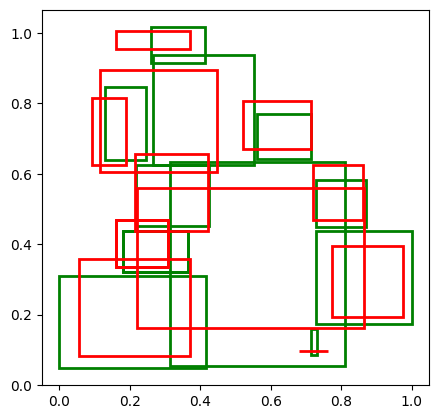

In [13]:
visualize_prediction(1)

In [31]:
def graph_layout_to_rgb(boxes, room_types, edge_index, size=512):
    import numpy as np, cv2

    N = len(boxes)

    room = np.zeros((size,size), np.float32)
    adj  = np.zeros((size,size), np.float32)
    typ  = np.zeros((size,size), np.float32)

    tmax = max(room_types) if len(room_types)>0 else 1
    centers = []

    for i,(cx,cy,w,h) in enumerate(boxes):
        x0 = int((cx-w/2)*size)
        y0 = int((cy-h/2)*size)
        x1 = int((cx+w/2)*size)
        y1 = int((cy+h/2)*size)

        x0,y0 = np.clip([x0,y0],0,size-1)
        x1,y1 = np.clip([x1,y1],0,size-1)

        inst_val = (i+1)/(N+1)

        mask = np.zeros((size,size), np.float32)
        mask[y0:y1,x0:x1] = 1.0

        room = np.maximum(room, mask*inst_val)
        typ  = np.maximum(typ,  mask*(room_types[i]/(tmax+1e-6)))

        cv2.rectangle(room,(x0,y0),(x1,y1),1.0,2)

        centers.append((int(cx*size), int(cy*size)))

    for k in range(edge_index.shape[1]):
        i,j = edge_index[:,k]
        cv2.line(adj, centers[i], centers[j], 1.0, 2)

    rgb = np.stack([room, adj, typ], axis=2)
    rgb = (rgb*255).astype(np.uint8)
    return rgb

In [40]:
model.eval()

data = test_dataset[11].to(device)

with torch.no_grad():
    pred = model(data)

boxes = pred.cpu().numpy()

# normalize boxes
xmin = (boxes[:,0] - boxes[:,2]/2).min()
ymin = (boxes[:,1] - boxes[:,3]/2).min()
xmax = (boxes[:,0] + boxes[:,2]/2).max()
ymax = (boxes[:,1] + boxes[:,3]/2).max()

boxes_norm = boxes.copy()
boxes_norm[:,0] = (boxes[:,0] - xmin) / (xmax - xmin + 1e-6)
boxes_norm[:,1] = (boxes[:,1] - ymin) / (ymax - ymin + 1e-6)
boxes_norm[:,2] = boxes[:,2] / (xmax - xmin + 1e-6)
boxes_norm[:,3] = boxes[:,3] / (ymax - ymin + 1e-6)

# extract types from one-hot
num_semantic = 7
room_types = data.x[:, :num_semantic].argmax(1).cpu().numpy()

edges = data.edge_index.cpu().numpy()

# ⭐ regenerate control image
control_img = graph_layout_to_rgb(boxes_norm, room_types, edges)

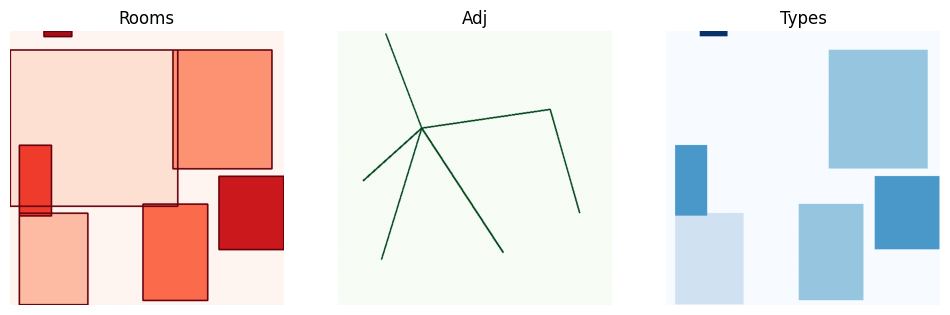

In [41]:
fig,ax = plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(control_img[:,:,0], cmap="Reds"); ax[0].set_title("Rooms")
ax[1].imshow(control_img[:,:,1], cmap="Greens"); ax[1].set_title("Adj")
ax[2].imshow(control_img[:,:,2], cmap="Blues"); ax[2].set_title("Types")
for a in ax: a.axis("off")

In [1]:
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
import torch

device = "cuda"

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_seg",
    torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to(device)

pipe.enable_xformers_memory_efficient_attention()

/home/dexter/projects/FloorPlan-Pipeline/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dexter/projects/FloorPlan-Pipeline/venv/lib64/python3.14/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Cancellation requested; stopping current tasks.


KeyboardInterrupt: 